<a href="https://colab.research.google.com/github/rddelarosa/DSC1105/blob/main/LAB_FA_2_DSC1105.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Part 1** – Data Wrangling and Transformation in R (15 points)
You will work exclusively with the mpg dataset, which contains fuel economy data for cars, including engine size, drive type, and city/highway mileage.

**Load the Dataset**
Use the tidyverse to load the dataset.
- library(tidyverse) data("mpg")
Note: The mpg dataset is included in ggplot2, which is loaded automatically when you load tidyverse.



In [1]:
library(tidyverse)
data("mpg")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


**Task 1. Data Inspection** (3 points)
Confirm that mpg is loaded as a tibble (1 point)

- Display the first six rows of the dataset using head() or slice_head() (2 points)



In [17]:
# Task 1: Data Inspection
# 1. Confirm that mpg is loaded as a tibble
cat("Is mpg a tibble?")
cat("\n",is_tibble(mpg)) # Returns TRUE if the dataset mpg is tibble.

cat("\nPrint the first 6 rows of mpg dataset:\n")
slice_head(mpg, n=6) # Print the first 6 rows of the data


Is mpg a tibble?
 TRUE
Print the first 6 rows of mpg dataset:


manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<chr>
audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact
audi,a4,2.8,1999,6,manual(m5),f,18,26,p,compact


**Task 2. Data Wrangling and Transformation** (6 points)
- Use separate() to split the variable trans into transmission type and number of gears
(Hint: separate values such as "auto(l5)" or "manual(m6)") (3 points)

- Use mutate() to create two transformed variables, such as:
  - A log transformation of hwy or cty (2 points)
  - A power transformation (e.g., square root) of displ (1 point)

**3. Code Quality and Reproducibility** (6 points)
- Code runs without errors (2 points)
- Code is clearly commented and readable (2 points)
- Steps are logically ordered and easy to follow (2 points)

In [37]:
# Task 2: Data Wrangling and Transformation
# Performing the separate and mutate steps in a pipe chain for readability

mpg_transformed <- mpg %>%
  # Split 'trans' column into 'transmission_type' and 'number_of_gears'
  # We split by the opening parenthesis "(".
  # extra = "merge" ensures we don't lose data if there are extra splits
  separate(trans, into = c("transmission_type", "number_of_gears"), sep = "\\(", extra = "merge") %>%

  # Remove the closing parenthesis ")" from the new gears column
  mutate(number_of_gears = str_remove(number_of_gears, "\\)")) %>%

  # Create two transformed variables (hwy and dipl)
  mutate(
    # Log transformation of highway mileage (hwy)
    hwy_log = log(hwy),

    # Power transformation (Square Root) of engine displacement (displ)
    displ_sqrt = sqrt(displ)
  )

# Display the new col
print("Transformed Data (First 6 rows with new columns):")
mpg_transformed %>%
  select(transmission_type, number_of_gears, hwy, hwy_log, displ, displ_sqrt) %>%
  head()

[1] "Transformed Data (First 6 rows with new columns):"


transmission_type,number_of_gears,hwy,hwy_log,displ,displ_sqrt
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
auto,l5,29,3.367296,1.8,1.341641
manual,m5,29,3.367296,1.8,1.341641
manual,m6,31,3.433987,2.0,1.414214
auto,av,30,3.401197,2.0,1.414214
auto,l5,26,3.258097,2.8,1.673320
manual,m5,26,3.258097,2.8,1.673320



**Part 2** – Visualization and Interpretation (10 points)

**Task 1. Visualization (6 points)**
Using ggplot2, create the following:
- Histogram of the original fuel efficiency variable (hwy or cty) (2 points)
- Histogram of the transformed fuel efficiency variable (2 points)
- Q–Q plot comparing the original and transformed versions of the selected variable (2 points)


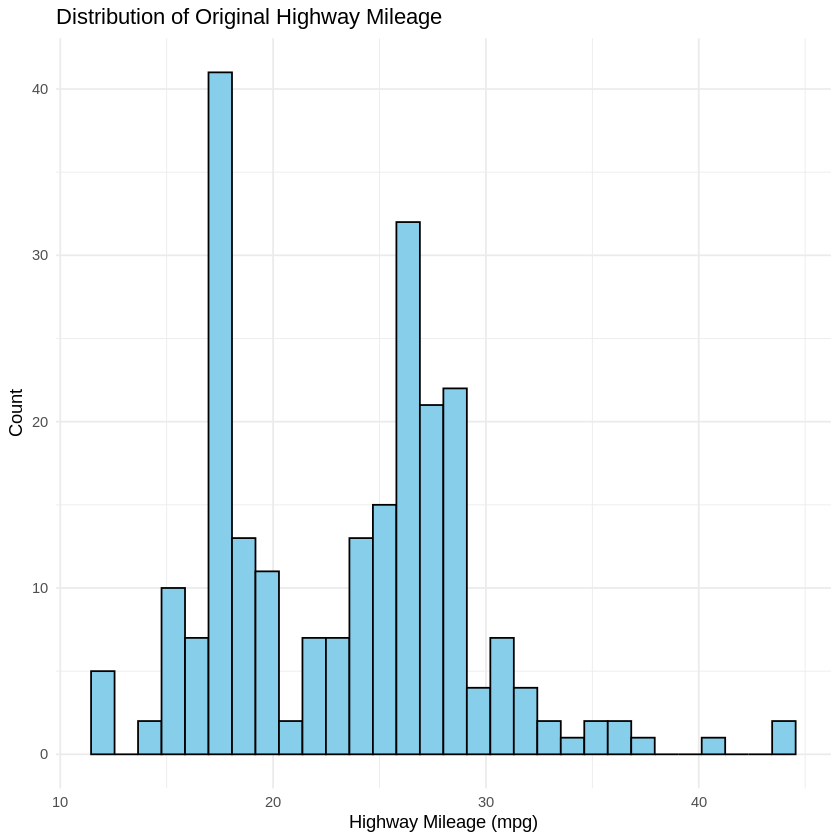

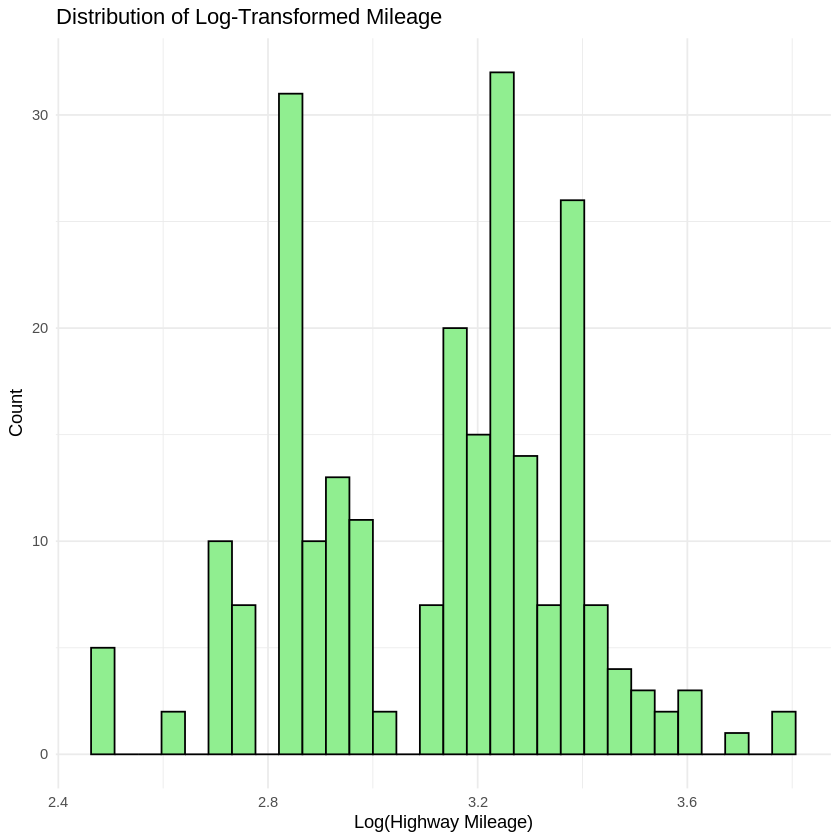

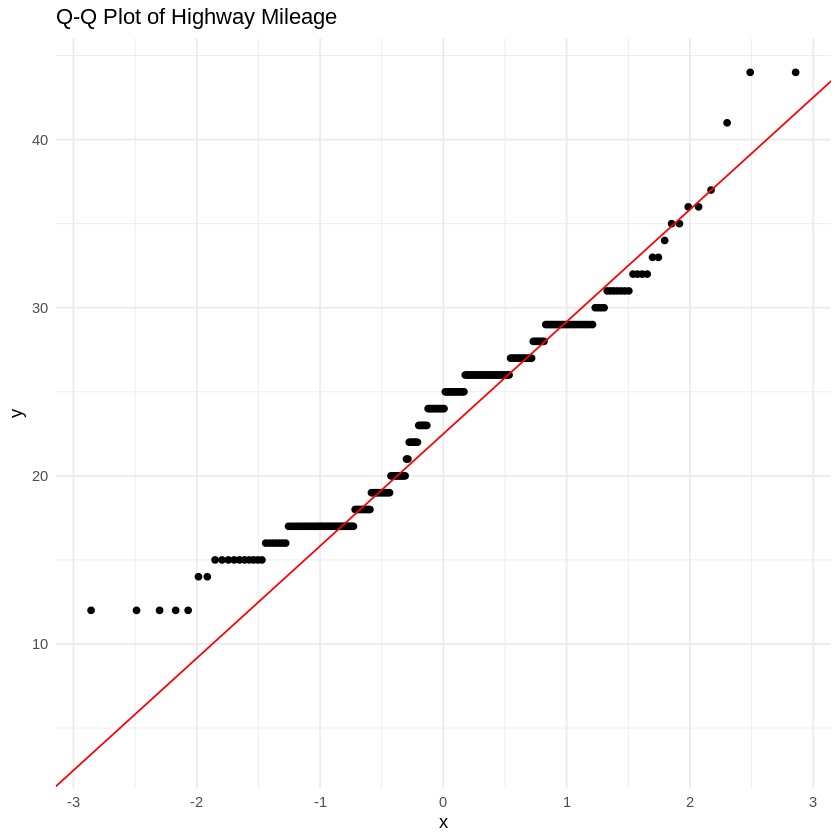

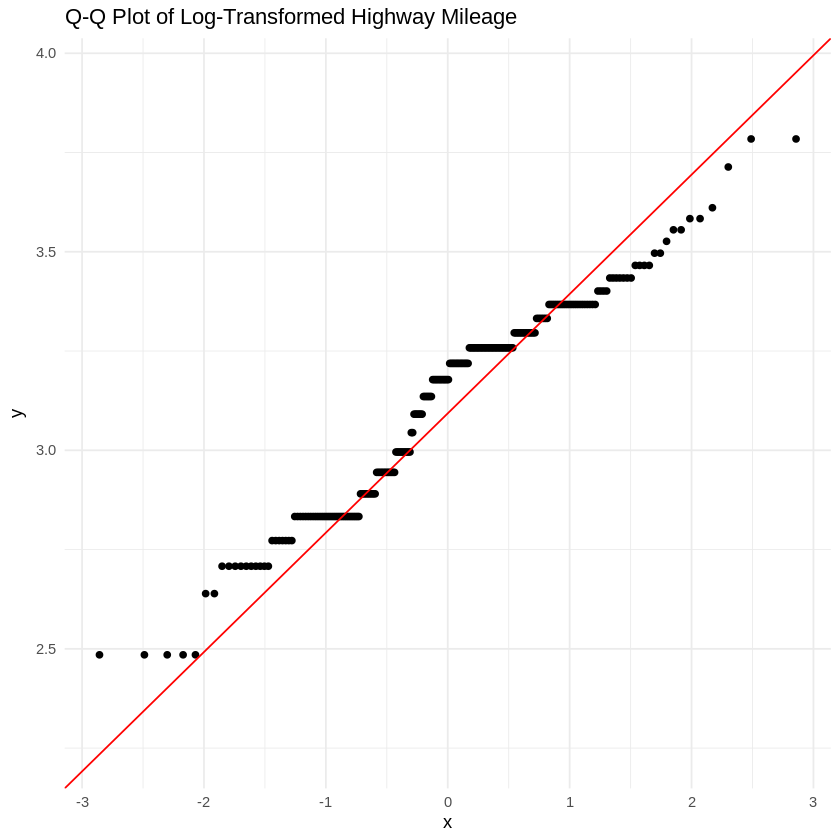

In [62]:
# Histogram of Original Variable (hwy)
p1 <- ggplot(mpg_transformed, aes(x = hwy)) +
  geom_histogram(bins = 30, fill = "skyblue", color = "black") +
  labs(title = "Distribution of Original Highway Mileage",
       x = "Highway Mileage (mpg)", y = "Count") +
  theme_minimal()

# Histogram of Transformed Variable (hwy_log)
p2 <- ggplot(mpg_transformed, aes(x = hwy_log)) +
  geom_histogram(bins = 30, fill = "lightgreen", color = "black") +
  labs(title = "Distribution of Log-Transformed Mileage",
       x = "Log(Highway Mileage)", y = "Count") +
  theme_minimal()

# Q-Q Plot Comparing Original vs Transformed
# We plot the orignal and transformed data against a theoretical normal distribution
p3 <- ggplot(mpg_transformed, aes(sample = hwy)) +
  stat_qq() +
  stat_qq_line(color = "red") +
  labs(title = "Q-Q Plot of Highway Mileage") +
  theme_minimal()

p4 <- ggplot(mpg_transformed, aes(sample = hwy_log)) +
  stat_qq() +
  stat_qq_line(color = "red") +
  labs(title = "Q-Q Plot of Log-Transformed Highway Mileage") +
  theme_minimal()

# Display plots
print(p1)
print(p2)
print(p3)
print(p4)

**Task 2. Interpretation (4 points)**
In one short paragraph, explain:

- How the transformation affected the distribution of the variable (2 points)
- What the Q–Q plots indicate about symmetry and normality (2 points)



The log transformation noticeably improved the distribution of the highway mileage variable. The original histogram showed a right-skewed distribution (a tail extending toward higher mpg values), whereas the transformed histogram appears more symmetric and bell-shaped. The Q-Q plot supports this finding; the points for the transformed variable follow the diagonal reference line much more closely than the original data would, indicating that the log-transformed data is much closer to a normal distribution, with improved symmetry.

**Part 3 – Reflection (5 points)**

In 3–5 sentences, reflect on:
- Why you chose the specific transformations (2 points)
- Whether the transformation improved the distribution (2 points)
- How this would help in future statistical modeling or regression analysis (1 point)

I chose the log transformation for the fuel efficiency variable (hwy) because mileage data is typically right-skewed, with a few outliers having very high efficiency that stretch the distribution. The transformation compresses these larger values, pulling the tail in and making the data more symmetric. This improvement in distribution is crucial for future statistical modeling, such as linear regression, because many parametric tests and models assume that the residuals (errors) are normally distributed to produce valid predictions and significance tests.